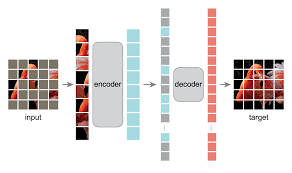

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import math
import torch.nn.functional as F

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device",device)

device cpu


## patch_embedding

In [ ]:
class PatchEmbedding(nn.Module):
  def __init__(self,patch_size,in_channels,embed_dim):
    super().__init__()
    self.patch_size = patch_size
    self.in_channels = in_channels
    self.proj = nn.Conv2d(
        in_channels = self.in_channels,
        out_channels=embed_dim,
        kernel_size = self.patch_size,
        stride = self.patch_size
    )
  def forward(self,x):
    # x = (B,8,125,125) considering the cern data
    x = self.proj(x) # shape = (B,768,25,25)
    x = x.flatten(2,-1) # shape = (B,768,625)
    x = x.transpose(2,1) # shape = (B,625,768)
    return x

In [ ]:
## testing
x = torch.zeros(32,8,125,125)
patch = PatchEmbedding(5,8,768)
x = patch(x)
x.shape

torch.Size([32, 625, 768])

## positional encoding

In [ ]:
class PositionalEncoding(nn.Module):
  def __init__(self,patches,embed_dim):
    super().__init__()
    ## img = (3,224,224) => (batch_size,patches,embed_dim)
    self.d_k = embed_dim
    self.patches = patches
    pe = torch.zeros(patches,self.d_k) # (197,768)
    div = torch.exp(torch.arange(0,self.d_k,2).float() * -(math.log(1000.0)/self.d_k)) # (1,384)
    ### range(0,df-2,2) => 2i
    ### -(math.log(1000.0)/self.d_k) => -log(1000.0)/d_k
    ### multiplication => (2i/d_k) * -log(100.000)
    ### exp = -1000.0^(2i/d_k) => 1/1000.o^(2i/dk)
    position = torch.arange(0,patches).float().unsqueeze(1) # (197,1)
    #print("before position")
    pe[:,0::2] = torch.sin(position*div) # only even positions are taken (197,1)*(1,384) = (197,384)
    pe[:,1::2] = torch.cos(position*div) # only the odd positions are taken(197,384)
    # (batch,197,384)
    #print("pe done ")
    pe = pe.unsqueeze(0) # adding the batch parameter
    self.register_buffer("pe",pe) # setting in the buffer to avoid the backtracking
  def forward(self,x):
    return x + (self.pe[:,:self.patches,:]).requires_grad_(False) # adding the positional vector => :self.patches are added to avoid the upscale in that dim

In [ ]:
x = torch.zeros(32,625,768)
positional = PositionalEncoding(625,768)
x = positional(x)
x.shape

torch.Size([32, 625, 768])

## Sampling

In [ ]:
## it is the uniform distribution that remove some patches from the data = 75% patches are removed
class SamplingHead(nn.Module):
  def __init__(self,batch,seq_len,mask_ratio):
    super().__init__()
    self.mask_ratio = mask_ratio
    self.uniform = torch.rand(batch,seq_len).to(x.device)
    self.len = int(seq_len*(1-mask_ratio))

  def forward(self,x):
    # x = (b,seq_len,embed) = (32,625,200)
    B,N,D = x.size()
    ids_shuffle = torch.argsort(self.uniform,dim=1) # [[[0.4,0.3,0.5]]] -> argsort -> [[[0,1,2]]] -> dim=1 -> [[1,0,2]] - to take the fist k values
    ids_restore = torch.argsort(ids_shuffle,dim=1) # [[[1,0,2]]] -> argsort , dim=1 -> [[[0,1,2]]] to keep the track which had sorted for inverse sampling
    ids_keep = ids_shuffle[:,:self.len] # only the 25% are considering
    x_masked = torch.gather(x,dim=1,index=ids_keep.unsqueeze(-1).repeat(1,1,D)) # here is like only taking the index values from the given tensor
    mask = torch.ones(B,N)
    mask[:,:self.len] = 0
    mask = torch.gather(mask,dim=1,index=ids_restore)
    return x_masked,mask,ids_restore

In [ ]:
sample = SamplingHead(32,625,0.75)
x,mask,ids_restore = sample(x)

In [ ]:
x.shape , mask.shape , ids_restore.shape

(torch.Size([32, 156, 768]), torch.Size([32, 625]), torch.Size([32, 625]))

In [ ]:
print(mask[0].shape)
mask # 1 = masked patch (removed) , 0 = visible patch

torch.Size([625])


tensor([[1., 0., 0.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 0., 1.,  ..., 0., 0., 1.],
        ...,
        [1., 0., 1.,  ..., 0., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 0., 0.,  ..., 1., 0., 0.]])

In [ ]:
ids_restore # it says like 137 = 0th position at 137 index
## it is use to restore the oririnal patches

tensor([[613,   1, 138,  ..., 246, 256,  87],
        [477, 195, 239,  ..., 183, 481, 309],
        [277, 132, 263,  ...,  53, 128, 369],
        ...,
        [405,   5, 353,  ...,  56, 182,  97],
        [436, 226, 492,  ..., 324, 223,   4],
        [218, 135, 147,  ..., 252,  46, 121]])

In [ ]:
class InverseSamplingHead(nn.Module):
    def __init__(self, masked_patches, embed_dim):
        super().__init__()
        self.masked_patches = masked_patches
        self.mask_token = nn.Parameter(torch.zeros(1,1,embed_dim))

    def forward(self, encoder_x, ids_restore):
        B, N, E = encoder_x.size()
        mask_tokens = self.mask_token.repeat(B, self.masked_patches, 1) # shape = (32,156,1)
        tokens = torch.cat([encoder_x, mask_tokens], dim=1) # (32,)
        x = torch.gather(
            tokens,
            dim=1,
            index=ids_restore.unsqueeze(-1).repeat(1,1,E)
        )
        return x

In [ ]:
inv_sample = InverseSamplingHead(625,768)
x = inv_sample(x,ids_restore)

In [ ]:
x.shape # original shape

torch.Size([32, 625, 768])

In [ ]:
x # here the 00 are masked

tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0518,  0.0684, -0.0512,  ...,  0.0186, -0.0237, -0.0070],
         [ 0.0518,  0.0684, -0.0512,  ...,  0.0186, -0.0237, -0.0070],
         ...,
         [ 0.0518,  0.0684, -0.0512,  ...,  0.0186, -0.0237, -0.0070],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0518,  0.0684, -0.0512,  ...,  0.0186, -0.0237, -0.0070]],

        [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0518,  0.0684, -0.0512,  ...,  0.0186, -0.0237, -0.0070],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 0.0518,  0.0684, -0.0512,  ...,  0.0186, -0.0237, -0.0070],
         [ 0.0000,  0.0000,  0.0000,  ...,  0

## Transformer components

In [ ]:
# what is in the transformer
## multihead attention
## residual
# layer norm
# fnn

In [ ]:
class LayerNorm(nn.Module):
  def __init__(self):
    super().__init__()
    self.eps = 0.01
    self.alpha = nn.Parameter(torch.ones(1))
    self.beta = nn.Parameter(torch.ones(1))
    pass
  def forward(self,x):
    mean = x.mean(dim=-1,keepdim=True)
    std = x.std(dim=-1,keepdim=True)
    return (self.alpha * ((x - mean)/(std+self.eps))) + self.beta

In [ ]:
class FeedForwardlayer(nn.Module):
  def __init__(self,patches,embed_dim):
    super().__init__()
    self.dim = 2048
    self.fc_1 = nn.Linear(embed_dim,self.dim)
    self.fc_2 = nn.Linear(self.dim,embed_dim)
  def forward(self,x):
    return self.fc_2(F.gelu(self.fc_1(x)))

In [ ]:
class ResidualBlock(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm = LayerNorm()
  def forward(self,X,sublayer):
    #print("in residual ")
    return X + sublayer(self.layer_norm(X)) # ada and norm
    ## here the sublayer is normed first then add

In [ ]:
## global linear attention
class MultiHeadAttention(nn.Module):
  def __init__(self,seq_len,embedding_dim,heads,head_dim):
    super().__init__()
    self.heads = heads
    self.head_dim = head_dim
    self.Q = nn.Linear(embedding_dim,embedding_dim)
    self.K = nn.Linear(embedding_dim,embedding_dim)
    self.V = nn.Linear(embedding_dim,embedding_dim)

  def feature_map(self,x):
    return torch.clamp(F.elu(x) + 1,min=0.0,max=5.0)

  def forward(self,x):
    # x = (32,100,128)
    B,L,E =  x.shape
    #print(type(L))
    q = self.feature_map(self.Q(x)).view(B,L, self.heads, self.head_dim).transpose(1, 2) # (32,100,128) => (32,100,2,64) => (32,2,100,64)
    k = self.feature_map(self.K(x)).view(B,L, self.heads, self.head_dim).transpose(1, 2)
    v = (self.V(x)).view(B,L, self.heads, self.head_dim).transpose(1, 2)
    # 2. Compute Global KV State (The associative trick)
    # Instead of chunks, we aggregate the entire image context at once.
    # kv shape: (B, heads, head_dim, head_dim)
    #print("k,q,v computed")
    kv = torch.matmul(k.transpose(-1, -2), v)
    #print("kv computed")
    # 3. Compute Normalization factor (Denominator)
    # z shape: (B, heads, head_dim, 1)
    z = k.sum(dim=2, keepdim=True).transpose(-1, -2)
    #print("z computed")
    # 4. Global Attention Output
    # num: (B, heads, L, head_dim)
    num = torch.matmul(q, kv)
    #print("num_computed")
    # den: (B, heads, L, 1)
    den = torch.matmul(q, z) + 1e-5
    #print("den computed")
    out = num / den
    out = out.transpose(1, 2).reshape(B, L, E)
    #print("out")
    return out

## Encoder block

In [ ]:
class EncoderBlock(nn.Module):
  def __init__(self,attention:MultiHeadAttention,fnn:FeedForwardlayer,patches,embed_dim):
    super().__init__()
    self.attention = attention
    self.fnn = fnn
    self.patches = patches
    self.embed_dim = embed_dim
    self.residual = nn.ModuleList([ResidualBlock() for _ in range(2)]) # we want and 2 residual layer connected
  def forward(self,X):
    X = self.residual[0](X,lambda x:self.attention(X)) ## here the attention is second layer (sublayer) and the X is the input which is going to add
    X = self.residual[1](X,lambda x:self.fnn(X))
    return X

## Decoder block

In [ ]:
class DecoderBlock(nn.Module):
  def __init__(self,attention:MultiHeadAttention,fnn:FeedForwardlayer,patches,embed_dim):
    super().__init__()
    self.attention = attention
    self.fnn = fnn
    self.patches = patches
    self.embed_dim = embed_dim
    self.residual = nn.ModuleList([ResidualBlock() for _ in range(2)]) # we want and 2 residual layer connected
    #self.low_dim_layer = nn.Linear(embed_dim,low_dim)
  def forward(self,X):
    #X = self.low_dim_layer(X) # as the decoder is light weigth so only taking small dim value
    #print("before attention")
    X = self.residual[0](X,lambda x:self.attention(X)) ## here the attention is second layer (sublayer) and the X is the input which is going to add
    #print("after attention")
    X = self.residual[1](X,lambda x:self.fnn(X))
    #print("after fnn")
    return X

In [ ]:
## testing
encoder_dim = 768
encoder_seq_len = 156
mask_ratio = 0.75
decoder_seq_len = 625
decoder_dim = 512
encoder_head = 12
encoder_head_dim = 64
decoder_head = 16
decoder_head_dim = 32
encoder_mask_patches = 156
num_patches = 625
patch_size = 5
layernorm = LayerNorm()
encoder_attention = MultiHeadAttention(encoder_seq_len,encoder_dim,encoder_head,encoder_head_dim) # 4,50
decoder_attention = MultiHeadAttention(decoder_seq_len,decoder_dim,decoder_head,decoder_head_dim) # 2,50 (32,625,100)
fnn_enc = FeedForwardlayer(encoder_mask_patches,encoder_dim)
fnn_dec = FeedForwardlayer(decoder_seq_len,decoder_dim)
encoder = EncoderBlock(encoder_attention,fnn_enc,encoder_seq_len,encoder_dim)
decoder = DecoderBlock(decoder_attention,fnn_dec,decoder_seq_len,decoder_dim)

In [ ]:
x_enc = torch.zeros(32,156,768)
x_op_enc = encoder(x_enc)
x_op_enc.shape

torch.Size([32, 156, 768])

In [ ]:
x_dec = torch.zeros(32,625,512)
x_op_dec = decoder(x_dec)
x_op_dec.shape

torch.Size([32, 625, 512])

In [ ]:
# encoder output
# masking
# linear positioning - encoder dim to decoder dim
# positional encoding
# decoder transformer block

## linear projection

In [ ]:
class LinearProjection(nn.Module):
  def __init__(self,encoder_dim,decoder_dim):
    super().__init__()
    self.linear_proj = nn.Linear(encoder_dim,decoder_dim)
  def forward(self,x):
    return self.linear_proj(x)


In [ ]:
lp = LinearProjection(768,512)
x = torch.zeros(32,625,768)
x = lp(x)
x.shape

torch.Size([32, 625, 512])

## Output

In [ ]:
class OutputHead(nn.Module):
  def __init__(self,embed_dim,decoder_dim):
    super().__init__()
    self.pred = nn.Linear(decoder_dim,embed_dim)
  def forward(self,x):
    # x = (32,625,512)
    B,P,E = x.size()
    x = self.pred(x)
    return x

In [ ]:
output = OutputHead(8,5,512,125)
x = torch.zeros(32,625,512)
output(x).shape

torch.Size([32, 8, 125, 125])

## MAE

In [ ]:
class MAE(nn.Module):
  def __init__(self,encoder:EncoderBlock,decoder:DecoderBlock,enc_positional:PositionalEncoding,dec_positional:PositionalEncoding,sample:SamplingHead,inv_sample:InverseSamplingHead,patch:PatchEmbedding,linearP:LinearProjection,output:OutputHead):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder
    self.enc_positional = enc_positional
    self.dec_positional = dec_positional
    self.sample = sample
    self.inv_sample = inv_sample
    self.patch = patch
    self.linearP = linearP
    self.output = output
  def forward(self,x):
    ## image = (32,8,125,125)
    x = self.patch(x)
    target = x.clone()
    # (32,625,200)
    x = self.enc_positional(x)
    x,mask,ids_restore = self.sample(x)
    # x = (32,156,200)
    x = self.encoder(x)
    # x = (32,156,200)
    x = self.inv_sample(x,ids_restore)
    # x = (32,625,200)
    x = self.linearP(x)
    # x = (32,625,100)
    x = self.dec_positional(x)
    x = self.decoder(x)
    # x = (32,625,100)
    x = self.output(x)
    # x = (32,8,125,125)
    return x,target,mask

In [ ]:
## testing
in_channels = 8
encoder_dim = 768
encoder_seq_len = 156
mask_ratio = 0.75
decoder_seq_len = 625
decoder_dim = 512
encoder_head = 12
encoder_head_dim = 64
decoder_head = 16
decoder_head_dim = 32
encoder_mask_patches = 156
num_patches = 625
patch_size = 5
img_size = 125
enc_positional = PositionalEncoding(num_patches,encoder_dim)
dec_positional = PositionalEncoding(num_patches,decoder_dim)
linearP = LinearProjection(encoder_dim,decoder_dim)
output = OutputHead(in_channels,patch_size,decoder_dim,img_size)

In [ ]:
mae = MAE(
    encoder,decoder,enc_positional,dec_positional,sample,inv_sample,patch,linearP,output
)

In [ ]:
mae

MAE(
  (encoder): EncoderBlock(
    (attention): MultiHeadAttention(
      (Q): Linear(in_features=768, out_features=768, bias=True)
      (K): Linear(in_features=768, out_features=768, bias=True)
      (V): Linear(in_features=768, out_features=768, bias=True)
    )
    (fnn): FeedForwardlayer(
      (fc_1): Linear(in_features=768, out_features=2048, bias=True)
      (fc_2): Linear(in_features=2048, out_features=768, bias=True)
    )
    (residual): ModuleList(
      (0-1): 2 x ResidualBlock(
        (layer_norm): LayerNorm()
      )
    )
  )
  (decoder): DecoderBlock(
    (attention): MultiHeadAttention(
      (Q): Linear(in_features=512, out_features=512, bias=True)
      (K): Linear(in_features=512, out_features=512, bias=True)
      (V): Linear(in_features=512, out_features=512, bias=True)
    )
    (fnn): FeedForwardlayer(
      (fc_1): Linear(in_features=512, out_features=2048, bias=True)
      (fc_2): Linear(in_features=2048, out_features=512, bias=True)
    )
    (residual): M

In [ ]:
x = torch.zeros(32,8,125,125)
mae(x).shape

torch.Size([32, 8, 125, 125])

## Training loop

In [ ]:
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from tqdm import tqdm
import os

def train_mae(
    model,
    train_loader,
    val_loader,
    device,
    epochs=50,
    lr=1e-3,
    weight_decay=0.05,
    save_path="checkpoint_mae.pth"
):

    model = model.to(device)

    optimizer = AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = OneCycleLR(
        optimizer,
        max_lr=lr,
        steps_per_epoch=len(train_loader),
        epochs=epochs
    )
    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    for epoch in range(epochs):
        # TRAIN
        model.train()
        train_loss_epoch = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in pbar:
            imgs = batch.to(device)
            optimizer.zero_grad()
            pred, target, mask = model(imgs) # the significance of the target is the mask patches the model want to know where the mask patches error had actually occured
            loss = (pred - target) ** 2
            loss = loss.mean(dim=-1)       # patch loss
            loss = (loss * mask).sum() / mask.sum()
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_loss_epoch += loss.item()
            pbar.set_postfix({
                "loss": loss.item(),
                "lr": scheduler.get_last_lr()[0]
            })

        train_loss_epoch /= len(train_loader)
        train_losses.append(train_loss_epoch)

        # VALIDATION

        model.eval()
        val_loss_epoch = 0
        with torch.no_grad():
            pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
            for batch in pbar:

                imgs = batch.to(device)
                pred, target, mask = model(imgs)
                loss = (pred - target) ** 2
                loss = loss.mean(dim=-1)
                loss = (loss * mask).sum() / mask.sum()
                val_loss_epoch += loss.item()
                pbar.set_postfix({
                    "val_loss": loss.item()
                })

        val_loss_epoch /= len(val_loader)
        val_losses.append(val_loss_epoch)

        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss: {train_loss_epoch:.6f}")
        print(f"Val Loss:   {val_loss_epoch:.6f}")

        if val_loss_epoch < best_val_loss:

            best_val_loss = val_loss_epoch

            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "train_losses": train_losses,
                "val_losses": val_losses,
                "best_val_loss": best_val_loss
            }, save_path)

            print("model saved.")

    return train_losses, val_losses